In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
import numpy as np
import pandana as pdna
import geopandas as gpd
import pandas as pd
import osmnx as ox
import math
import networkx as nx
import sys
import matplotlib.pyplot as plt
sys.path.insert(0, 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index')
import there

C:\Users\z3258367\AppData\Local\Temp\ipykernel_18668\2764289510.py:3: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


Choose a projected CRS to be used for all distance calculations.

In [4]:
folder = "C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Colouring data & results\\"
proj_crs = "EPSG:7856"

place = 'Adelaide, Australia'
place_gdf = ox.geocode_to_gdf(place).to_crs(proj_crs)

## Import Data

Data sources:
1. OSM POIs
5. Employment data - find govt source

In [5]:
poi_dictionary = there.get_poi_dict()

In [6]:
osm_pois = there.poi_downloader(place_gdf, poi_dictionary, proj_crs)

In [7]:
employment_centrs = gpd.read_file((folder + 
                        "Shared Aus Data\\SA_Employment_points.gpkg")).to_crs(proj_crs)

employment_centrs['category'] = 'employment'

Need to remove potential overlap between different data sources (and inside some data sources). For now I'm not worrying about this when using only OSM data. Then take this combined POI set and clip it to the study area: should be the same area as is covered by the network. This is important otherwise points outside the network may be erroneously linked to the network.

In [8]:
pois = pd.concat([osm_pois, employment_centrs])

pois = gpd.clip(pois, place_gdf.to_crs(proj_crs))

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\array.py:1406: UserWarning: CRS not set for some of the concatenation inputs. Setting output's CRS as GDA2020 / MGA zone 56 (the single non-null crs provided).
  warnings.warn(


### POI parameters

Choose drive index weightings, and output the sums of each category and the total to check. The drive index will be out of 100 regardless of this sum, but it is important to note that eg. shopping is only '10% of the walk index' if shopping is 10 out of 100.

In [9]:
poi_parameters = pd.read_csv((folder + 
                              "Shared Aus Data\\poi_parameters_5.csv"),
                            index_col=0)
poi_parameters = poi_parameters.sort_index()

poi_weights = poi_parameters['weight'].copy()
poi_lambdas = poi_parameters['diminishing_returns_constant'].copy()
poi_variables = poi_parameters['variable'].copy()
poi_nums = poi_parameters['num_pois'].copy()
poi_gammas = poi_parameters['distance_constant'].copy()

total = sum(poi_weights)
print("total: ", total)

total:  100.0


In [10]:
# change this to match the column containing job counts in employment dataframe
poi_variables.loc['employment'] = 'Job no'
# change this to make employment score more accurate (higher number) or to reduce index calculation time (low number)
poi_nums.loc['employment'] = 1200

## Walking

In [11]:
walk_dist=2400

In [12]:
walk_network = there.prepare_walk_net(place_gdf, proj_crs)

In [13]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.

results_walk_cluster10, result_pois_10 = there.cluster_index(walk_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=walk_dist, loop=5, chain_frac=1/3, trace=True)         

Finished category: education
Maximum score: 5.508320911835544 out of 14.3
Finished category: employment
Maximum score: 13.173983238889045 out of 31.9
Finished category: errands
Maximum score: 4.288824289159167 out of 8.9
Finished category: recreation
Maximum score: 11.483333125673196 out of 23.3
Finished category: shopping
Maximum score: 10.526899411769573 out of 21.6
loop: 0
Finished category: education
Maximum score: 6.363139658203742 out of 14.3
Finished category: employment
Maximum score: 15.794844187467904 out of 31.9
Finished category: errands
Maximum score: 5.1483233903306225 out of 8.9
Finished category: recreation
Maximum score: 13.874029167877305 out of 23.3
Finished category: shopping
Maximum score: 12.692963261093999 out of 21.6
loop: 1
Finished category: education
Maximum score: 6.506855302830793 out of 14.3
Finished category: employment
Maximum score: 16.321131305030523 out of 31.9
Finished category: errands
Maximum score: 5.3322852849528175 out of 8.9
Finished category: 

In [14]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.

results_walk_cluster0, result_pois_0 = there.cluster_index(walk_network, pois, poi_dictionary, poi_weights, poi_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=walk_dist, loop=1, chain_frac=0, trace=True)

Finished category: education
Maximum score: 8.262481367753315 out of 14.3
Finished category: employment
Maximum score: 19.760974858333583 out of 31.9
Finished category: errands
Maximum score: 6.4332364337387515 out of 8.9
Finished category: recreation
Maximum score: 17.22499968850979 out of 23.3
Finished category: shopping
Maximum score: 15.790349117654369 out of 21.6
loop: 0


In [140]:
len(results_walk_cluster10), len(result_pois_10), len(results_walk_cluster0)

(120175, 11842, 120175)

In [24]:
output = 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index\\Clustering\\'
area = 'Adelaide'

result_pois_10.filter(regex='^geometry|index|node_id|THERE').to_file((output + area + "_walk_poi_5up" + ".gpkg"), driver="GPKG")

### Tables

In [27]:
results_walk_cluster10['no_cluster'] = results_walk_cluster0['THERE_Index']
results_walk_cluster10['diff4'] = results_walk_cluster10['no_cluster'] - results_walk_cluster10[('THERE_' + str(4))]
results_walk_cluster10['diff3'] = results_walk_cluster10['no_cluster'] - results_walk_cluster10[('THERE_' + str(3))]
results_walk_cluster10['percent_diff4'] = results_walk_cluster10['diff4']/results_walk_cluster10['no_cluster']
results_walk_cluster10['percent_diff3'] = results_walk_cluster10['diff3']/results_walk_cluster10['no_cluster']
results_walk_cluster10['change1'] = results_walk_cluster10[('THERE_' + str(1))] - results_walk_cluster10[('THERE_' + str(0))]
results_walk_cluster10['change2'] = results_walk_cluster10[('THERE_' + str(2))] - results_walk_cluster10[('THERE_' + str(1))]
results_walk_cluster10['change3'] = results_walk_cluster10[('THERE_' + str(3))] - results_walk_cluster10[('THERE_' + str(2))]
results_walk_cluster10['change4'] = results_walk_cluster10[('THERE_' + str(4))] - results_walk_cluster10[('THERE_' + str(3))]
results_walk_cluster10['propchange1'] = results_walk_cluster10['change1']/results_walk_cluster10[('THERE_' + str(0))]
results_walk_cluster10['propchange2'] = results_walk_cluster10['change2']/results_walk_cluster10[('THERE_' + str(1))]
results_walk_cluster10['propchange3'] = results_walk_cluster10['change3']/results_walk_cluster10[('THERE_' + str(2))]
results_walk_cluster10['propchange4'] = results_walk_cluster10['change4']/results_walk_cluster10[('THERE_' + str(3))]

In [29]:
# generate summary table where rows are columns THERE_0 to THERE_9, with max, mean, and % change from previous
results_walk_cluster10.loc[:,'THERE_0':'no_cluster'].describe().T

,count,mean,std,min,25%,50%,75%,max
THERE_0,120175.0,15.279682,6.602117,0.000000e+00,11.478741,14.955521,18.996639,43.113335
THERE_1,120175.0,16.847154,7.737605,0.000000e+00,12.335985,16.294839,20.983931,52.079192
THERE_2,120175.0,17.030142,7.929934,0.000000e+00,12.410743,16.425569,21.202799,53.915100
THERE_3,120175.0,17.053963,7.963288,0.000000e+00,12.416922,16.440357,21.229121,54.287593
THERE_4,120175.0,17.057385,7.969260,0.000000e+00,12.417694,16.441811,21.232010,54.362717
diff4,120175.0,5.862138,2.026955,0.000000e+00,4.779074,5.997230,7.267514,10.387411
diff3,120175.0,5.865561,2.030893,0.000000e+00,4.779992,5.998714,7.270882,10.445948
percent_diff4,119120.0,0.265025,0.024005,1.593828e-01,0.253994,0.267806,0.279216,0.333174
percent_diff3,119120.0,0.265126,0.023871,1.605445e-01,0.254097,0.267862,0.279251,0.333174
change1,120175.0,1.567471,1.193388,0.000000e+00,0.855706,1.322183,1.989710,8.965856


### Visualisation

In [103]:
import matplotlib_scalebar 
from matplotlib_scalebar.scalebar import ScaleBar
from shapely.geometry import Point

In [104]:
envelope = result_pois_10.to_crs("EPSG:4326").unary_union.envelope
envelope = gpd.GeoDataFrame({'geometry': envelope, 'convex_hull':[1]},crs=proj_crs)
graph_envelope = gpd.GeoDataFrame({'geometry': result_pois_10.to_crs("EPSG:4326").unary_union.envelope, 'convex_hull':[1]},crs="EPSG:4326")

In [105]:
Australia = gpd.read_file("C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Data\\ABS Data\\2016_GCCSA_aust_shape\\GCCSA_2016_AUST.shp").to_crs(proj_crs)
graph_area = Australia.to_crs("EPSG:4326")
graph_area = graph_area.clip(graph_envelope)

c:\Users\z3258367\Anaconda3\envs\ox_ua\lib\site-packages\geopandas\tools\clip.py:67: DeprecationWarning: In a future version, `df.iloc[:, i] = newvals` will attempt to set the values inplace instead of always setting a new array. To retain the old behavior, use either `df[df.columns[i]] = newvals` or, if columns are non-unique, `df.isetitem(i, newvals)`
  clipped.loc[


In [106]:
# option to use every third row to speed up plotting. The maps are still considerably over-plotted, for large cities at this figure size.

graph_data = result_pois_10.iloc[::1, :].to_crs("EPSG:4326")

points = gpd.GeoSeries([Point(138, -35), Point(139, -35)], crs=4326)  # Geographic WGS 84 - degrees
points = points.to_crs(3857) # Projected WGS 84 - meters
distance_meters = points[0].distance(points[1])

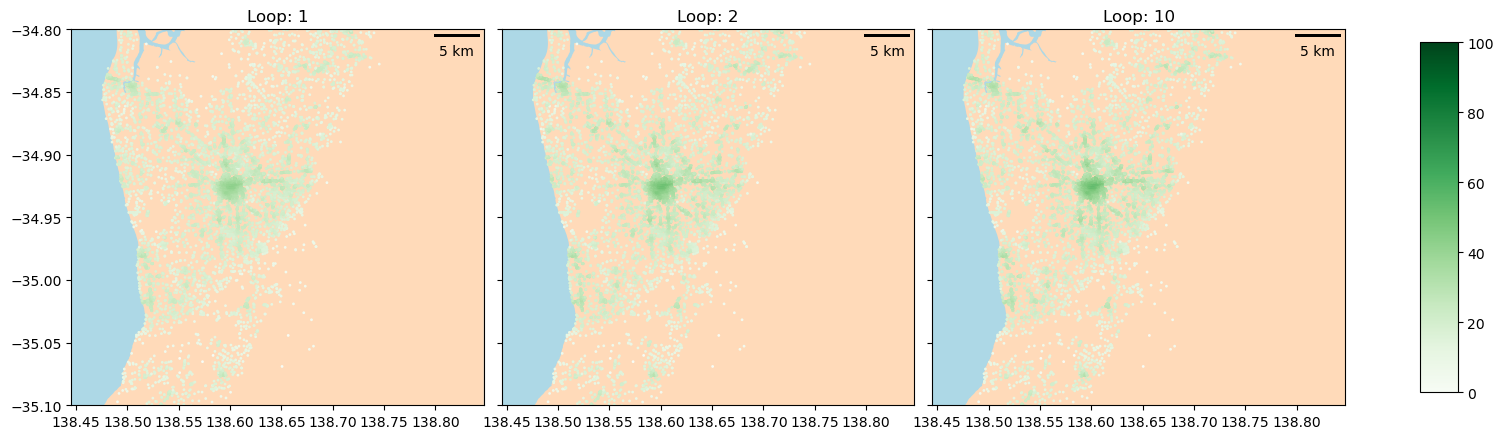

In [107]:
loops = [0,1,9]

fig, axs = plt.subplots(1,len(loops), sharex=True, sharey=True, 
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(15,5))

for ax in axs.ravel():
    graph_area.plot(ax = ax, zorder=1, color='peachpuff')
    ax.add_artist(ScaleBar(distance_meters, frameon=False))

for i, loop in enumerate(loops):
    ax = axs[i]
    graph_data.plot(ax = ax, zorder=2,
                    column = ('THERE_' + str(loop)),
                    cmap='Greens', markersize=1, vmin=0, vmax = 100)
    ax.set_title("Loop: "+ str(loop+1))
    # limit y axes to -35.1 to -34.8
    ax.set_ylim(-35.1, -34.8)    
    
plt.tight_layout()

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap='Greens', norm=plt.Normalize(vmin=0, vmax=100))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95,0.15,0.025,0.7])
fig.colorbar(sm, cax=cbar_ax)

In [108]:
np.mean(graph_data[('THERE_' + str(9))]-graph_data[('THERE_' + str(0))])

2.8096039479394483

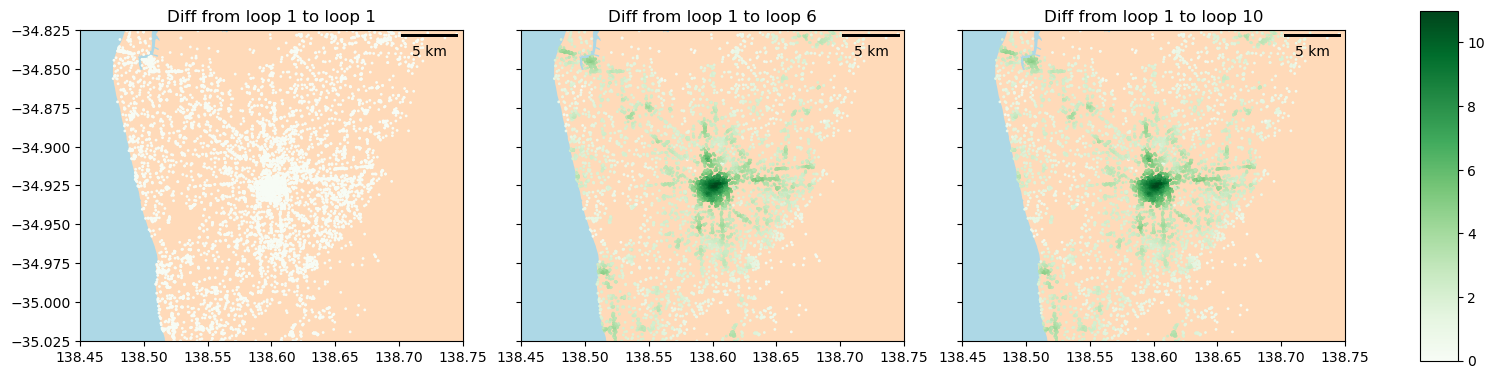

: 

In [109]:
loops = [0,5,9]
colour = 'Greens'

fig, axs = plt.subplots(1,len(loops), sharex=True, sharey=True, 
                       subplot_kw=dict(facecolor="lightblue",xmargin=0,ymargin=0), 
                       figsize=(15,5))

for ax in axs.ravel():
    graph_area.plot(ax = ax, zorder=1, color='peachpuff')
    ax.add_artist(ScaleBar(distance_meters, frameon=False))

for i, loop in enumerate(loops):
    ax = axs[i]
    graph_data.plot(ax = ax, zorder=2,
                    column = graph_data[('THERE_' + str(loop))]-graph_data[('THERE_' + str(0))],
                    cmap=colour, markersize=1, vmin=0, vmax = 11)
    ax.set_title("Diff from loop 1 to loop "+ str(loop+1))
    # limit y axes to -35.1 to -34.8
    ax.set_ylim(-35.025, -34.825)
    ax.set_xlim(138.45, 138.75)    
    
plt.tight_layout()

# Create colorbar scale
sm = plt.cm.ScalarMappable(cmap=colour, norm=plt.Normalize(vmin=0, vmax=11))
 # empty array for the data range
sm._A = []
# add the colorbar to the figure
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.95,0.15,0.025,0.7])
fig.colorbar(sm, cax=cbar_ax)

### Old

In [26]:
# summarise results
((result_pois_10['THERE_4']/result_pois_10['THERE_3'])-(result_pois_10['THERE_3']/result_pois_10['THERE_2'])).max()

-1.3561152201191362e-11

In [23]:
print(max(results_walk_cluster5['THERE_Index']), np.mean(results_walk_cluster5['THERE_Index']))
# new upwards method, matches to results below with 30 cycles

54.37409722261169 16.987844245609317


In [21]:
# old result 87.2, 47.4
print(max(results_walk_cluster0['THERE_Index']), np.mean(results_walk_cluster0['THERE_Index']))
print(max(results_walk_cluster3['THERE_Index']), np.mean(results_walk_cluster3['THERE_Index']))
#print(max(results_walk_cluster5['THERE_Index']), np.mean(results_walk_cluster5['THERE_Index']))
print(max(results_walk_cluster30['THERE_Index']), np.mean(results_walk_cluster30['THERE_Index']))

64.4758813977666 22.789714381260165
57.155537743979956 18.04936244403587
54.164385069290546 16.9545206245612


# 2. Driving

In [30]:
drive_gammas = poi_gammas.copy()
drive_gammas = drive_gammas.replace(to_replace=0.001, value=0.000075)
drive_dist=24000

In [32]:
# Create a pandana network with data extracted from an OSMNX graph
drive_network = there.prepare_drive_net(place_gdf, proj_crs)

In [33]:
%%capture --no-stdout 

results_drive_cluster5, result_pois_drive_cluster5 = there.cluster_index(drive_network, pois, poi_dictionary, poi_weights, drive_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=drive_dist, loop=5, chain_frac=1/3, trace=True)

Finished category: education
Maximum score: 6.904886324059351 out of 14.3
Finished category: employment
Maximum score: 19.83991621099953 out of 31.9
Finished category: errands
Maximum score: 4.3894344761508295 out of 8.9
Finished category: recreation
Maximum score: 11.50064299206549 out of 23.3
Finished category: shopping
Maximum score: 10.65822831376597 out of 21.6
loop: 0
Finished category: education
Maximum score: 8.689916020089075 out of 14.3
Finished category: employment
Maximum score: 25.05564097193874 out of 31.9
Finished category: errands
Maximum score: 5.54725000486519 out of 8.9
Finished category: recreation
Maximum score: 14.551593526391464 out of 23.3
Finished category: shopping
Maximum score: 13.462947549369412 out of 21.6
loop: 1
Finished category: education
Maximum score: 9.154111358868533 out of 14.3
Finished category: employment
Maximum score: 26.42632540891277 out of 31.9
Finished category: errands
Maximum score: 5.854160564505332 out of 8.9
Finished category: recreat

In [34]:
%%capture --no-stdout 

results_drive_cluster0, result_pois_drive_cluster0 = there.cluster_index(drive_network, pois, poi_dictionary, poi_weights, drive_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=drive_dist, loop=1, chain_frac=0, trace=True)

Finished category: education
Maximum score: 10.357329486089025 out of 14.3
Finished category: employment
Maximum score: 29.759874316499292 out of 31.9
Finished category: errands
Maximum score: 6.584151714226244 out of 8.9
Finished category: recreation
Maximum score: 17.25096448809823 out of 23.3
Finished category: shopping
Maximum score: 15.987342470648962 out of 21.6
loop: 0


In [39]:
results_drive_cluster5['no_cluster'] = results_drive_cluster0['THERE_Index']
results_drive_cluster5['diff4'] = results_drive_cluster5['no_cluster'] - results_drive_cluster5[('THERE_' + str(4))]
results_drive_cluster5['diff3'] = results_drive_cluster5['no_cluster'] - results_drive_cluster5[('THERE_' + str(3))]
results_drive_cluster5['percent_diff4'] = results_drive_cluster5['diff4']/results_drive_cluster5['no_cluster']
results_drive_cluster5['percent_diff3'] = results_drive_cluster5['diff3']/results_drive_cluster5['no_cluster']
results_drive_cluster5['change1'] = results_drive_cluster5[('THERE_' + str(1))] - results_drive_cluster5[('THERE_' + str(0))]
results_drive_cluster5['change2'] = results_drive_cluster5[('THERE_' + str(2))] - results_drive_cluster5[('THERE_' + str(1))]
results_drive_cluster5['change3'] = results_drive_cluster5[('THERE_' + str(3))] - results_drive_cluster5[('THERE_' + str(2))]
results_drive_cluster5['change4'] = results_drive_cluster5[('THERE_' + str(4))] - results_drive_cluster5[('THERE_' + str(3))]
results_drive_cluster5['propchange1'] = results_drive_cluster5['change1']/results_drive_cluster5[('THERE_' + str(0))]*100
results_drive_cluster5['propchange2'] = results_drive_cluster5['change2']/results_drive_cluster5[('THERE_' + str(1))]*100
results_drive_cluster5['propchange3'] = results_drive_cluster5['change3']/results_drive_cluster5[('THERE_' + str(2))]*100
results_drive_cluster5['propchange4'] = results_drive_cluster5['change4']/results_drive_cluster5[('THERE_' + str(3))]*100

In [40]:
# generate summary table where rows are columns THERE_0 to THERE_9, with max, mean, and % change from previous
results_drive_cluster5.loc[:,'THERE_0':'propchange4'].describe().T

,count,mean,std,min,25%,50%,75%,max
THERE_0,62435.0,41.519392,5.069728,14.037923,38.767507,42.301864,44.927517,53.104879
THERE_1,62435.0,50.542453,6.994681,16.062317,46.569471,51.478067,55.255271,67.139350
THERE_2,62435.0,52.560320,7.588360,16.393667,48.173089,53.496383,57.663046,70.838638
THERE_3,62435.0,53.022559,7.757757,16.452889,48.509851,53.946588,58.234084,71.812043
THERE_4,62435.0,53.130722,7.804307,16.464146,48.581938,54.050445,58.371716,72.067878
no_cluster,62435.0,62.279088,7.604592,21.056884,58.151260,63.452796,67.391275,79.657318
diff4,62435.0,9.148366,0.553411,4.592738,8.834078,9.221045,9.564073,10.148885
diff3,62435.0,9.256529,0.523052,4.603995,8.959642,9.330081,9.641125,10.205023
percent_diff4,62435.0,0.149691,0.023779,0.095263,0.133611,0.147641,0.164132,0.226616
percent_diff3,62435.0,0.151361,0.023190,0.098476,0.135683,0.149320,0.165384,0.227000


In [106]:
def result_rounding(results):
    # reduces results size for export
    # score columns such as there.there_index, employment_subtotal etc -> 3 decimal places
    # distance columns such as employment1 -> 0 decimal places (nearest metre)
    # avoid doing anything to connect_id, x or y
    rounding_dict = {**{k:3 for k in results.columns if "Index" in k or "." in k or "THERE" in k
                        and 'connect_id' not in k},
                     **{k:0 for k in results.columns if "Index" not in k and "." not in k and "THERE" not in k
                        and k != 'x'
                        and k != 'y'}}
    return results.round(rounding_dict)

def export(result, area, resultname):
    result_gdf = gpd.GeoDataFrame(result_rounding(result), 
                                    geometry = gpd.GeoSeries.from_xy(result.x, result.y, crs=proj_crs))
    result_gdf.to_file((output + area + resultname + ".gpkg"), driver="GPKG")
    result_rounding(result.filter(regex='x|y$|_')).to_csv(output + area + resultname + ".csv")


In [117]:
# filter result_pois to only include columns: geometry, source, index, node_id, and columns like THERE
result_pois_test = result_pois.filter(regex='^geometry|index|node_id|THERE')

In [139]:
result_pois.columns

Index(['node_id', 'source', 'geometry', 'created_by', 'amenity', 'name',
       'postal_code', 'brand', 'operator', 'operator:wikidata',
       ...
       'THERE_0', 'THERE_1', 'THERE_2', 'THERE_3', 'THERE_4', 'THERE_5',
       'THERE_6', 'THERE_7', 'THERE_8', 'THERE_9'],
      dtype='object', length=413)

In [119]:
output = 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index\\Clustering\\'
area = 'Adelaide'

result_pois.filter(regex='^geometry|index|node_id|THERE').to_file((output + area + "_walk_poi_10" + ".gpkg"), driver="GPKG")
export(results_cluster50, area, '_cluster50')
result_pois_drive.filter(regex='^geometry|index|node_id|THERE').to_file((output + area + "_drive_poi_50" + ".gpkg"), driver="GPKG")

In [43]:
# import
output = 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Clustering results\\'
area = 'Adelaide'
results_cluster50 = gpd.read_file((output + area + "_drive_poi_50" + ".gpkg"))

In [51]:
results_cluster50.index = results_cluster50['index']

In [54]:
results_cluster50['add_THERE_0'] = result_pois_drive_cluster5['THERE_0']
results_cluster50['add_THERE_1'] = result_pois_drive_cluster5['THERE_1']
results_cluster50['add_THERE_2'] = result_pois_drive_cluster5['THERE_2']
results_cluster50['add_THERE_3'] = result_pois_drive_cluster5['THERE_3']
results_cluster50['add_THERE_4'] = result_pois_drive_cluster5['THERE_4']

In [56]:
results_cluster50_edit = results_cluster50.copy()
results_cluster50_edit['THERE_0'] = results_cluster50['add_THERE_0']
results_cluster50_edit['THERE_1'] = results_cluster50['add_THERE_1']
results_cluster50_edit['THERE_2'] = results_cluster50['add_THERE_2']
results_cluster50_edit['THERE_3'] = results_cluster50['add_THERE_3']
results_cluster50_edit['THERE_4'] = results_cluster50['add_THERE_4']
results_cluster50_edit = results_cluster50_edit.drop(columns=['add_THERE_0', 'add_THERE_1', 'add_THERE_2', 'add_THERE_3', 'add_THERE_4'])

In [65]:
results_cluster50_edit

,index,node_id,primaryindex,THERE,THERE_0,THERE_1,THERE_2,THERE_3,THERE_4,THERE_5,...,THERE_41,THERE_42,THERE_43,THERE_44,THERE_45,THERE_46,THERE_47,THERE_48,THERE_49,geometry
index,,,,,,,,,,,,,,,,,,,,,
301425126,301425126,599250409,NaN,29.117219,24.817819,28.427117,29.002217,29.098326,29.114856,29.118030,...,29.117219,29.117219,29.117219,29.117219,29.117219,29.117219,29.117219,29.117219,29.117219,POINT (-824970.958 5992269.318)
308975346,308975346,599250361,NaN,28.165149,24.040697,27.506058,28.055674,28.147221,28.162921,28.165920,...,28.165149,28.165149,28.165149,28.165149,28.165149,28.165149,28.165149,28.165149,28.165149,POINT (-825501.277 5992385.024)
3142714948,3142714948,599250391,NaN,29.100127,24.812147,28.412518,28.985589,29.081310,29.097769,29.100935,...,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,POINT (-825441.340 5992516.154)
308975345,308975345,599250391,NaN,29.100127,24.812147,28.412518,28.985589,29.081310,29.097769,29.100935,...,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,29.100127,POINT (-825413.836 5992596.155)
297465783,297465783,6163734198,NaN,40.804991,33.901759,39.628876,40.603349,40.771175,40.800532,40.806433,...,40.804991,40.804991,40.804991,40.804991,40.804991,40.804991,40.804991,40.804991,40.804991,POINT (-825462.180 5998854.914)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1222675791,1222675791,1838964909,NaN,41.310964,34.108875,40.046175,41.090272,41.275718,41.309050,41.312611,...,41.310964,41.310964,41.310964,41.310964,41.310964,41.310964,41.310964,41.310964,41.310964,POINT (-811130.053 6077996.005)
1222240171,1222240171,410912902,NaN,41.543240,34.293896,40.269742,41.320765,41.507424,41.540969,41.544898,...,41.543240,41.543240,41.543240,41.543240,41.543240,41.543240,41.543240,41.543240,41.543240,POINT (-811233.069 6078084.928)
1222721105,1222721105,430166510,NaN,38.637203,32.135829,37.515066,38.440908,38.603516,38.632566,38.638638,...,38.637203,38.637203,38.637203,38.637203,38.637203,38.637203,38.637203,38.637203,38.637203,POINT (-809625.845 6078132.091)


In [83]:
# find integer location index of max value of THERE_20 in results_cluster50_edit
results_cluster50_edit.index.get_loc(results_cluster50_edit['THERE_20'].idxmax())


2830

In [134]:
results_cluster50_edit.iloc[::283].iloc[::2].loc[:,'THERE_0':'THERE_9'].T

index,301425126,188,188331325,81106450,377834064,2371407776,6084302455,3624137925,57110968,2832888001,...,1529451684,282459978,1057568435,6920190397,7150487635,6917367489,5321114734,35929334,584309831,948052594
THERE_0,24.817819,40.824539,36.463074,44.158142,49.230528,53.104879,45.388163,47.719343,46.643464,46.123898,...,42.236696,49.956464,46.586525,48.794233,52.429373,46.730651,43.664175,45.410688,36.011130,38.629015
THERE_1,28.427117,49.218550,43.145342,54.193600,61.522672,67.139350,55.872051,58.991527,57.864664,56.803485,...,51.344293,62.498901,57.750769,60.858381,66.193198,57.856812,53.225700,56.015564,42.818659,46.121923
THERE_2,29.002217,50.976479,44.387095,56.529922,64.624210,70.838638,58.330524,61.660500,60.607530,59.294759,...,53.364703,65.674408,60.486903,63.882489,69.807095,60.556079,55.339143,58.539323,44.152343,47.599104
THERE_3,29.098326,51.352364,44.621429,57.084950,65.413253,71.812043,58.915018,62.296429,61.286116,59.881128,...,53.825851,66.484642,61.169209,64.649022,70.755770,61.221851,55.812071,59.149589,44.420067,47.895637
THERE_4,29.114856,51.434510,44.666362,57.219108,65.615322,72.067878,59.055790,62.449195,61.455697,60.020499,...,53.933901,66.692709,61.341606,64.844999,71.004730,61.388339,55.919379,59.299237,44.474881,47.956268
THERE_5,29.118030,51.463649,44.678769,57.268142,65.694044,72.203397,59.006614,62.508594,61.520209,60.070277,...,53.972702,66.774890,61.408249,64.921807,71.112222,61.377799,55.954050,59.189370,44.498660,47.963207
THERE_6,29.117362,51.460760,44.676997,57.263951,65.688210,72.196248,59.002163,62.503670,61.515116,60.065724,...,53.969247,66.768914,61.403216,64.916155,71.105261,61.372880,55.950363,59.184805,44.496585,47.960905
THERE_7,29.117245,51.460131,44.676655,57.262941,65.686718,72.194368,59.001097,62.502496,61.513847,60.064650,...,53.968439,66.767381,61.401945,64.914712,71.103433,61.371653,55.949532,59.183689,44.496159,47.960433
THERE_8,29.117224,51.459991,44.676589,57.262694,65.686335,72.193874,59.000838,62.502213,61.513529,60.064393,...,53.968246,66.766986,61.401621,64.914340,71.102954,61.371344,55.949341,59.183413,44.496070,47.960334
THERE_9,29.117220,51.459959,44.676575,57.262633,65.686236,72.193744,59.000775,62.502144,61.513448,60.064331,...,53.968198,66.766884,61.401538,64.914245,71.102828,61.371265,55.949297,59.183344,44.496051,47.960313


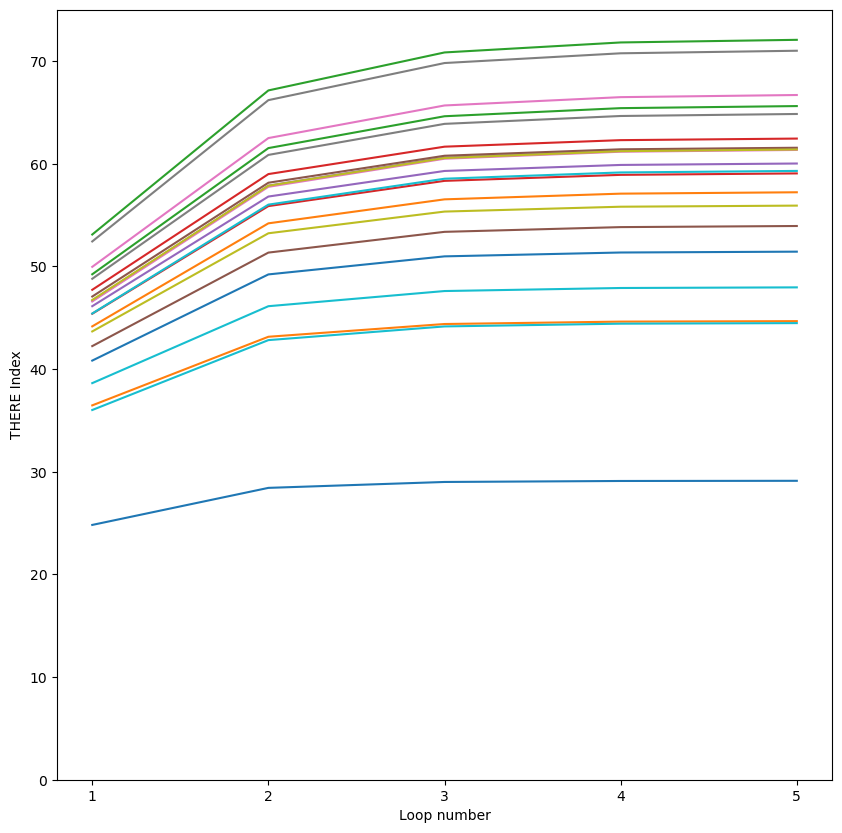

In [139]:
# plot results_cluster50_edit.iloc[[1]] columns THERE_0 to THERE_49, as a line graph
fig, ax = plt.subplots(1,1, figsize=(10,10))
# colour lines by THERE_0
results_cluster50_edit.iloc[::283].iloc[::2].loc[:,'THERE_0':'THERE_4'].T.plot(ax=ax, legend=False,cmap='tab10')
ax.set_ylim(0,75)
# set x axis to be labelled 1 to 10 instead of THERE_0 to THERE_9
ax.set_xticks(range(5))
ax.set_xticklabels(range(1,6))
ax.set_xlabel("Loop number")
ax.set_ylabel("THERE Index")
plt.show()

In [89]:
result_pois.columns[result_pois.dtypes=='list']

Index([], dtype='object')

In [76]:
print(result_pois.columns[350:400])

Index(['cycling', 'mtb', 'status', 'payment:card', 'contact:tripadvisor',
       'brand:website', 'cuisine_1', 'cuisine_2', 'addr:suburb:en', 'parking',
       'diet:dairy_free', 'ref:isil', 'changing_table', 'access:conditional',
       'owner', 'source:area', 'surface_1', 'name_1', 'orig_geometry', 'fid_2',
       'MB_CODE16', 'MB_CAT16', 'SA1_MAIN16', 'SA1_7DIG16', 'SA2_MAIN16',
       'SA2_5DIG16', 'SA2_NAME16', 'SA3_CODE16', 'SA3_NAME16', 'SA4_CODE16',
       'SA4_NAME16', 'GCC_CODE16', 'GCC_NAME16', 'STE_CODE16', 'STE_NAME16',
       'AREASQKM16', 'primaryindex', 'DZN_CODE_2016', 'SA2_MAINCODE_2016',
       'SA2_5DIGITCODE_2016', 'SA2_NAME_2016', 'STATE_CODE_2016',
       'STATE_NAME_2016', 'AREA_ALBERS_SQKM', 'Job no', 'Name', 'Block',
       'Job count', 'DZN/Block ID', 'MB Job Count'],
      dtype='object')


In [48]:
((result_pois_drive['THERE_6']/result_pois_drive['THERE_5'])-(result_pois_drive['THERE_5']/result_pois_drive['THERE_4']))

index
301425126     0.000111
308975346     0.000109
3142714948    0.000111
308975345     0.000111
297465783     0.000138
                ...   
1222675791    0.000150
1222240171    0.000150
1222721105    0.000141
181469729     0.000150
513752645     0.000149
Length: 11796, dtype: float64

In [24]:
result_pois['THERE_0'].std()/result_pois['THERE_0'].mean(), result_pois['THERE_1'].std()/result_pois['THERE_1'].mean(), result_pois['THERE_2'].std()/result_pois['THERE_2'].mean(), result_pois['THERE_3'].std()/result_pois['THERE_3'].mean(), result_pois['THERE_4'].std()/result_pois['THERE_4'].mean()

(0.37165878706345296,
 0.40852191846225666,
 0.4177850001653325,
 0.4198123004624231,
 0.4202301616293053)

In [54]:
result_pois_drive['THERE_0'].std()/result_pois_drive['THERE_0'].mean(), result_pois_drive['THERE_1'].std()/result_pois_drive['THERE_1'].mean(), result_pois_drive['THERE_2'].std()/result_pois_drive['THERE_2'].mean(), result_pois_drive['THERE_3'].std()/result_pois_drive['THERE_3'].mean(), result_pois_drive['THERE_4'].std()/result_pois_drive['THERE_4'].mean(), result_pois_drive['THERE_5'].std()/result_pois_drive['THERE_5'].mean(), result_pois_drive['THERE_9'].std()/result_pois_drive['THERE_9'].mean()

(0.11491123120671677,
 0.13909824503817242,
 0.1423251761963746,
 0.142506256351387,
 0.14243052770545378,
 0.1423879863516332,
 0.1423659278054136)

In [44]:
print(max(results_drive_cluster10['THERE_Index']), np.mean(results_drive_cluster10['THERE_Index']))

72.19374414336937 53.131184250315286


In [ ]:
# sanity check
print(max(results_drive_cluster0['THERE_Index']), np.mean(results_drive_cluster0['THERE_Index']))
print(max(results_drive_cluster3['THERE_Index']), np.mean(results_drive_cluster3['THERE_Index']))
print(max(results_drive_cluster5['THERE_Index']), np.mean(results_drive_cluster5['THERE_Index']))

79.62524601703664 62.17421133453636
74.6663438726601 55.67271218708105
71.36040910974242 51.338379422110854


# 3. Cycling

In [97]:
cycle_gammas = poi_gammas.copy()
cycle_gammas = cycle_gammas.replace(to_replace=0.001, value=0.0002)
cycle_dist = 12000

In [98]:
cycle_network = there.prepare_cycle_net(place_gdf, proj_crs)

In [99]:
%%capture --no-stdout 

results_cycle_cluster5, result_pois_cycle_cluster5 = there.cluster_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist, loop=5, chain_frac=1/3, trace=True)

Finished category: education
Maximum score: 6.3990584811511475 out of 14.3
Finished category: employment
Maximum score: 14.59001821842742 out of 31.9
Finished category: errands
Maximum score: 4.313367180067989 out of 8.9
Finished category: recreation
Maximum score: 11.48477001775306 out of 23.3
Finished category: shopping
Maximum score: 10.57029805308526 out of 21.6
loop: 0
Finished category: education
Maximum score: 7.539951625267117 out of 14.3
Finished category: employment
Maximum score: 17.59059132394374 out of 31.9
Finished category: errands
Maximum score: 5.198485040229484 out of 8.9
Finished category: recreation
Maximum score: 14.034035624763195 out of 23.3
Finished category: shopping
Maximum score: 12.812426381232875 out of 21.6
loop: 1
Finished category: education
Maximum score: 7.743249113987596 out of 14.3
Finished category: employment
Maximum score: 18.212081913571375 out of 31.9
Finished category: errands
Maximum score: 5.383925901601255 out of 8.9
Finished category: recre

In [100]:
%%capture --no-stdout 

results_cycle_cluster0, result_pois_cycle_cluster0 = there.cluster_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist, loop=1, chain_frac=0, trace=True)

Finished category: education
Maximum score: 9.598587721726716 out of 14.3
Finished category: employment
Maximum score: 21.885027327641094 out of 31.9
Finished category: errands
Maximum score: 6.470050770101984 out of 8.9
Finished category: recreation
Maximum score: 17.227155026629596 out of 23.3
Finished category: shopping
Maximum score: 15.855447079627883 out of 21.6
loop: 0


In [101]:
results_cycle_cluster5['no_cluster'] = results_cycle_cluster0['THERE_Index']
results_cycle_cluster5['diff4'] = results_cycle_cluster5['no_cluster'] - results_cycle_cluster5[('THERE_' + str(4))]
results_cycle_cluster5['diff3'] = results_cycle_cluster5['no_cluster'] - results_cycle_cluster5[('THERE_' + str(3))]
results_cycle_cluster5['percent_diff4'] = results_cycle_cluster5['diff4']/results_cycle_cluster5['no_cluster']
results_cycle_cluster5['percent_diff3'] = results_cycle_cluster5['diff3']/results_cycle_cluster5['no_cluster']
results_cycle_cluster5['change1'] = results_cycle_cluster5[('THERE_' + str(1))] - results_cycle_cluster5[('THERE_' + str(0))]
results_cycle_cluster5['change2'] = results_cycle_cluster5[('THERE_' + str(2))] - results_cycle_cluster5[('THERE_' + str(1))]
results_cycle_cluster5['change3'] = results_cycle_cluster5[('THERE_' + str(3))] - results_cycle_cluster5[('THERE_' + str(2))]
results_cycle_cluster5['change4'] = results_cycle_cluster5[('THERE_' + str(4))] - results_cycle_cluster5[('THERE_' + str(3))]
results_cycle_cluster5['propchange1'] = results_cycle_cluster5['change1']/results_cycle_cluster5[('THERE_' + str(0))]*100
results_cycle_cluster5['propchange2'] = results_cycle_cluster5['change2']/results_cycle_cluster5[('THERE_' + str(1))]*100
results_cycle_cluster5['propchange3'] = results_cycle_cluster5['change3']/results_cycle_cluster5[('THERE_' + str(2))]*100
results_cycle_cluster5['propchange4'] = results_cycle_cluster5['change4']/results_cycle_cluster5[('THERE_' + str(3))]*100

In [102]:
# generate summary table where rows are columns THERE_0 to THERE_9, with max, mean, and % change from previous
results_cycle_cluster5.loc[:,'THERE_0':'propchange4'].describe().T

,count,mean,std,min,25%,50%,75%,max
THERE_0,107606.0,22.448832,7.351481,0.000000e+00,18.655385,22.965310,27.361257,44.900430
THERE_1,107606.0,25.452431,8.802162,0.000000e+00,20.676221,25.811401,31.228957,54.381094
THERE_2,107606.0,25.881023,9.072178,0.000000e+00,20.903368,26.176855,31.779067,56.356277
THERE_3,107606.0,25.945336,9.121835,0.000000e+00,20.930466,26.225571,31.858779,56.765806
THERE_4,107606.0,25.955433,9.131016,0.000000e+00,20.934340,26.232672,31.871909,56.850506
no_cluster,107606.0,33.673248,11.027222,0.000000e+00,27.983077,34.447965,41.041886,67.350645
diff4,107606.0,7.717815,2.015639,0.000000e+00,7.002159,8.202691,9.138463,10.650381
diff3,107606.0,7.727912,2.021684,0.000000e+00,7.006482,8.209749,9.152563,10.689993
percent_diff4,106904.0,0.236257,0.024939,1.550637e-01,0.222931,0.236809,0.251617,0.332934
percent_diff3,106904.0,0.236507,0.024750,1.563317e-01,0.223236,0.237000,0.251733,0.332934


In [ ]:
%%capture --no-stdout 
#hides FutureWarning related to Pandana. turn off if something is not working.
results_cycle_cluster5 = there.cluster_index(cycle_network, pois, poi_dictionary, poi_weights, cycle_gammas,
                            poi_nums, poi_lambdas, poi_variables, distance=cycle_dist, loop=5, trace=TRUE)

Finished category: education
Maximum score: 9.598587721726716 out of 14.3
Finished category: employment
Maximum score: 21.885025511323178 out of 31.9
Finished category: errands
Maximum score: 6.47405119861956 out of 8.9
Finished category: recreation
Maximum score: 17.22479502854438 out of 23.3
Finished category: shopping
Maximum score: 15.811815196887398 out of 21.6
Finished category: education
Maximum score: 8.25592880676208 out of 14.3
Finished category: employment
Maximum score: 19.36514475661962 out of 31.9
Finished category: errands
Maximum score: 5.724233477136338 out of 8.9
Finished category: recreation
Maximum score: 15.4866554178584 out of 23.3
Finished category: shopping
Maximum score: 14.048903242072788 out of 21.6
Finished category: education
Maximum score: 7.425671238452959 out of 14.3
Finished category: employment
Maximum score: 17.685224253483867 out of 31.9
Finished category: errands
Maximum score: 5.247470673595077 out of 8.9
Finished category: recreation
Maximum score

In [ ]:
print(max(results_cycle_cluster0['THERE_Index']), np.mean(results_cycle_cluster0['THERE_Index']))
print(max(results_cycle_cluster3['THERE_Index']), np.mean(results_cycle_cluster3['THERE_Index']))
print(max(results_cycle_cluster5['THERE_Index']), np.mean(results_cycle_cluster5['THERE_Index']))

66.9965534089027 33.436925011508194
59.53433057328335 27.416036424676978
54.5595153495371 23.402110700122833


# 4. Transit

In [120]:
gtfs_path='C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\' + 'Walkability\\Other Cities\\Colouring data & results\\'  + "Adelaide Data\\gtfs_static_10.2.22"

In [121]:
# earlier results were with gamma 0.025, but have now changed to 0.05.
wgs_pois = pois.to_crs("EPSG:4326")
transit_max_time = 90
# need to change the distance/time decay
transit_gammas = poi_gammas.copy()
transit_gammas = transit_gammas.replace(to_replace=0.001, value=0.05)

In [1]:
transit_ped_net, osm_net = there.prepare_transit_net(place_gdf, proj_crs, gtfs_path, walk_network)

NameError: name 'there' is not defined

In [69]:
# check package versions loaded
import urbanaccess as ua
pd.__version__, gpd.__version__, nx.__version__, ox.__version__, pdna.__version__, ua.__version__

('1.5.3', '0.12.2', '3.1', '1.4.0', '0.6.1', '0.2.2')

In [ ]:
transit_results_cluster0 = there.transit_cluster_index(transit_ped_net, osm_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=1)
transit_results_cluster3 = there.transit_cluster_index(transit_ped_net, osm_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=2, chain_frac=0.3,
                                                       prev_results = transit_results_cluster0)
transit_results_cluster5 = there.transit_cluster_index(transit_ped_net, osm_net, wgs_pois, poi_dictionary, poi_weights, transit_gammas, poi_nums, poi_lambdas, poi_variables, transit_max_time, loop=2, chain_frac=0.5,
                                                       prev_results = transit_results_cluster0)


Finished category: education
Maximum score: 8.279497363900411 out of 14.3
Finished category: employment
Maximum score: 19.790036589377063 out of 31.9
Finished category: errands
Maximum score: 6.416060158799384 out of 8.9
Finished category: recreation
Maximum score: 17.21778156803663 out of 23.3
Finished category: shopping
Maximum score: 15.830443411453793 out of 21.6
Finished category: education
Maximum score: 6.837235517494036 out of 14.3
Finished category: employment
Maximum score: 15.808758001865082 out of 31.9
Finished category: errands
Maximum score: 5.667306375125379 out of 8.9
Finished category: recreation
Maximum score: 15.224883007860633 out of 23.3
Finished category: shopping
Maximum score: 13.993757386186351 out of 21.6
Finished category: education
Maximum score: 5.9755287649529665 out of 14.3
Finished category: employment
Maximum score: 14.348892483666843 out of 31.9
Finished category: errands
Maximum score: 5.196289032341311 out of 8.9
Finished category: recreation
Maximum

In [ ]:
print(max(transit_results_cluster0['THERE_Index']), np.mean(transit_results_cluster0['THERE_Index']))
print(max(transit_results_cluster3['THERE_Index']), np.mean(transit_results_cluster3['THERE_Index']))
print(max(transit_results_cluster5['THERE_Index']), np.mean(transit_results_cluster5['THERE_Index']))

64.65686022334123 23.16903739683916
54.70653369592934 17.049546584024124
49.953184527938106 14.08271201557515


## Export results

In [95]:
output = 'C:\\Users\\z3258367\\OneDrive - UNSW\\#PhD\\Walkability\\Other Cities\\Open-Walk-Index\\Clustering\\'
area = 'Adelaide'

Reduce the number of decimal places before export, distances do not need to be below 1m.

In [ ]:
def result_rounding(results):
    # reduces results size for export
    # score columns such as there.there_index, employment_subtotal etc -> 3 decimal places
    # distance columns such as employment1 -> 0 decimal places (nearest metre)
    # avoid doing anything to connect_id, x or y
    rounding_dict = {**{k:3 for k in results.columns if "Index" in k or "." in k
                        and 'connect_id' not in k},
                     **{k:0 for k in results.columns if "Index" not in k and "." not in k
                        and k != 'x'
                        and k != 'y'}}
    return results.round(rounding_dict)

def export(result, area, resultname):
    result_gdf = gpd.GeoDataFrame(result_rounding(result), 
                                    geometry = gpd.GeoSeries.from_xy(result.x, result.y, crs=proj_crs))
    result_gdf.to_file((output + area + resultname + ".gpkg"), driver="GPKG")
    result_rounding(result.filter(regex='x|y$|_')).to_csv(output + area + resultname + ".csv")

In [ ]:
export(results_walk_cluster0, area, '_walk_cluster0')
export(results_walk_cluster3, area, '_walk_cluster3')
export(results_walk_cluster5, area, '_walk_cluster5')

In [ ]:
export(results_drive_cluster0, area, '_drive_cluster0')
export(results_drive_cluster3, area, '_drive_cluster3')
export(results_drive_cluster5, area, '_drive_cluster5')
export(results_cycle_cluster0, area, '_cycle_cluster0')
export(results_cycle_cluster3, area, '_cycle_cluster3')
export(results_cycle_cluster5, area, '_cycle_cluster5')
export(transit_results_cluster0, area, '_transit_cluster0')
export(transit_results_cluster3, area, '_transit_cluster3')
export(transit_results_cluster5, area, '_transit_cluster5')